# 1) Reading Dataset
---

Step 0: Importing necessary modules

In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Step 1: Loading Factory dataset

In [43]:
df = pd.read_csv('factory.csv')

Step 2: Displaying rows & understanding the data

In [44]:
df

,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,5,True,3,162.0,False,NaN,NaN,NaN,NaN,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,2,True,4,147.0,False,NaN,NaN,40.92,NaN,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,True,6,0.0,True,NaN,NaN,NaN,NaN,2
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,...,1,False,4,161.0,False,NaN,NaN,NaN,NaN,0
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,...,2,False,1,765.0,False,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,MC_499995,Vacuum_Packer,2011,14425,65.42,16.50,81.95,59.21,73.67,255.87,...,3,False,0,820.0,False,NaN,NaN,NaN,NaN,0
499996,MC_499996,Conveyor_Belt,2003,75501,44.83,12.88,64.94,73.69,29.25,198.37,...,1,False,4,34.0,False,NaN,NaN,NaN,NaN,0
499997,MC_499997,CMM,2039,19855,37.26,11.46,70.70,70.70,49.04,156.59,...,2,False,4,815.0,False,NaN,NaN,NaN,NaN,0
499998,MC_499998,Dryer,2035,86823,67.72,16.76,77.45,97.00,15.40,132.33,...,2,True,0,99.0,False,NaN,NaN,NaN,NaN,2


In [45]:
df[['Last_Maintenance_Days_Ago', 'Maintenance_History_Count']]

,Last_Maintenance_Days_Ago,Maintenance_History_Count
0,153,4
1,136,5
2,258,1
3,43,4
4,346,4
...,...,...
499995,282,4
499996,208,4
499997,185,7
499998,274,3


Step 3: Statistics & other information about the data

In [46]:
df.describe()

,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,Failure_History_Count,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
count,500000.000000,500000.000000,500000.000000,500000.00000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,15156.000000,30340.000000,45624.000000,45214.000000,500000.000000
mean,2019.962360,50012.424764,59.997682,9.99114,75.003477,69.456568,64.114159,149.922161,182.257866,5.003128,2.000588,3.000840,452.422338,74.995513,119.917514,39.984794,499.760966,0.602098
std,11.829812,28861.849078,14.986973,4.99953,9.990791,18.847444,23.152998,79.955937,105.552537,2.238043,1.413087,1.730541,288.971269,10.035133,15.017048,9.989653,50.012057,1.203647
min,2000.000000,0.000000,-15.730000,-17.82000,23.650000,0.000000,0.000000,-222.740000,0.000000,0.000000,0.000000,0.000000,0.000000,34.970000,52.680000,-0.160000,296.440000,0.000000
25%,2010.000000,25055.000000,49.890000,6.62000,68.270000,56.540000,48.130000,96.090000,91.000000,3.000000,1.000000,2.000000,200.000000,68.250000,109.820000,33.200000,465.940000,0.000000
50%,2020.000000,49973.000000,60.000000,10.00000,75.000000,70.030000,65.010000,149.950000,182.000000,5.000000,2.000000,3.000000,451.000000,74.950000,119.860000,40.030000,499.770000,0.000000
75%,2030.000000,74995.000000,70.050000,13.36000,81.730000,83.540000,81.840000,203.900000,274.000000,6.000000,3.000000,4.000000,700.000000,81.682500,130.072500,46.750000,533.307500,1.000000
max,2040.000000,100000.000000,127.330000,32.47000,120.700000,100.000000,100.000000,544.200000,365.000000,18.000000,12.000000,13.000000,1133.000000,114.320000,185.380000,80.790000,694.170000,11.000000


In [47]:
df[['Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index']].isna().sum()

Laser_Intensity           484844
Hydraulic_Pressure_bar    469660
Coolant_Flow_L_min        454376
Heat_Index                454786
dtype: int64

In [48]:
df.shape

(500000, 22)

In [49]:
df.columns # 22 initial columns

Index(['Machine_ID', 'Machine_Type', 'Installation_Year', 'Operational_Hours',
       'Temperature_C', 'Vibration_mms', 'Sound_dB', 'Oil_Level_pct',
       'Coolant_Level_pct', 'Power_Consumption_kW',
       'Last_Maintenance_Days_Ago', 'Maintenance_History_Count',
       'Failure_History_Count', 'AI_Supervision', 'Error_Codes_Last_30_Days',
       'Remaining_Useful_Life_days', 'Failure_Within_7_Days',
       'Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min',
       'Heat_Index', 'AI_Override_Events'],
      dtype='str')

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Machine_ID                  500000 non-null  str    
 1   Machine_Type                500000 non-null  str    
 2   Installation_Year           500000 non-null  int64  
 3   Operational_Hours           500000 non-null  int64  
 4   Temperature_C               500000 non-null  float64
 5   Vibration_mms               500000 non-null  float64
 6   Sound_dB                    500000 non-null  float64
 7   Oil_Level_pct               500000 non-null  float64
 8   Coolant_Level_pct           500000 non-null  float64
 9   Power_Consumption_kW        500000 non-null  float64
 10  Last_Maintenance_Days_Ago   500000 non-null  int64  
 11  Maintenance_History_Count   500000 non-null  int64  
 12  Failure_History_Count       500000 non-null  int64  
 13  AI_Supervision           

Step 4: Visuals

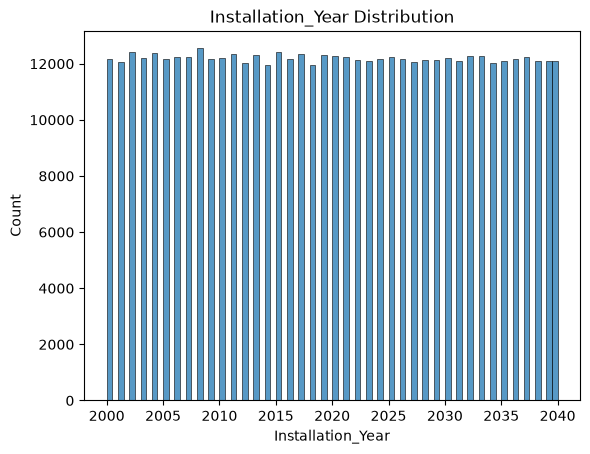

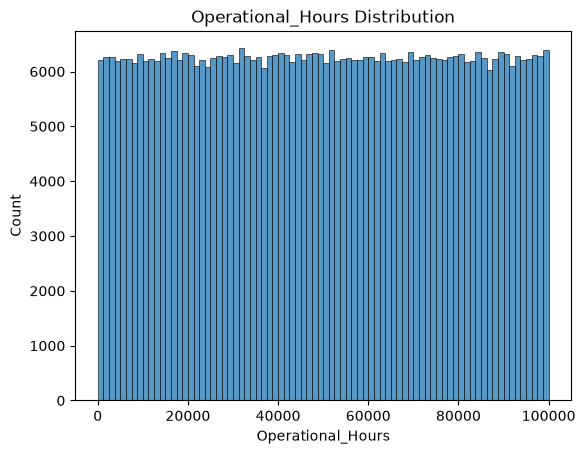

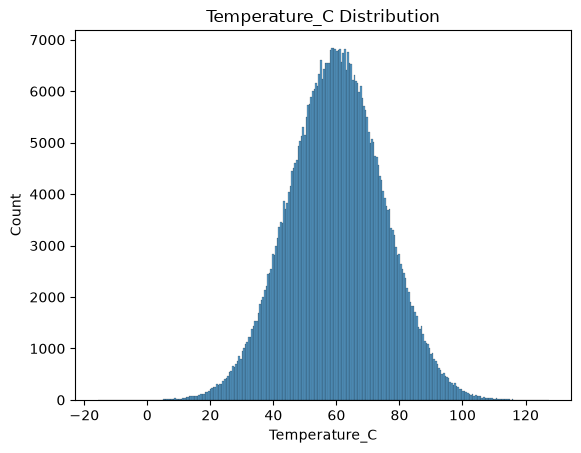

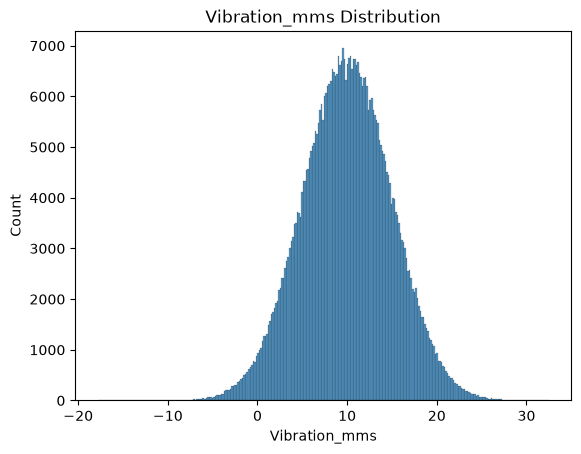

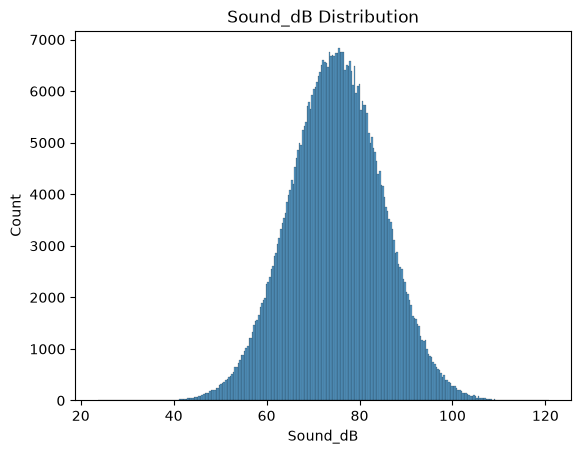

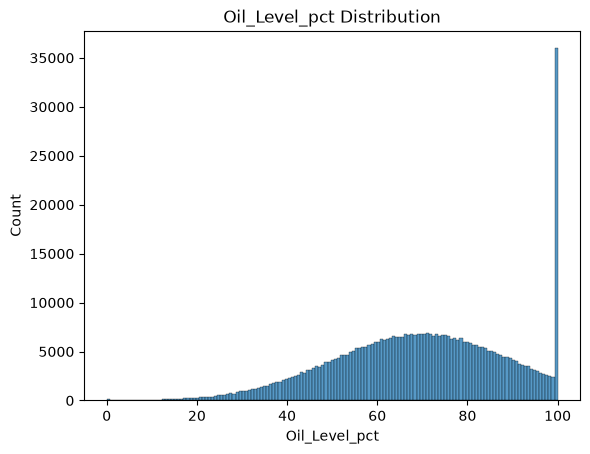

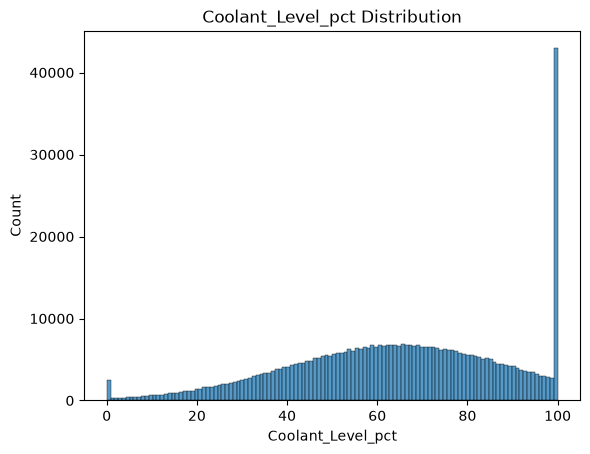

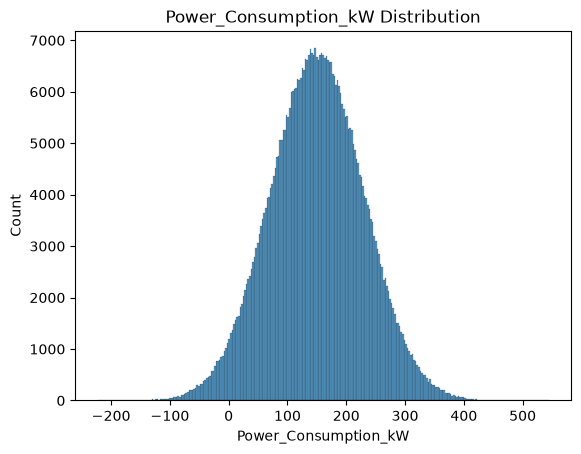

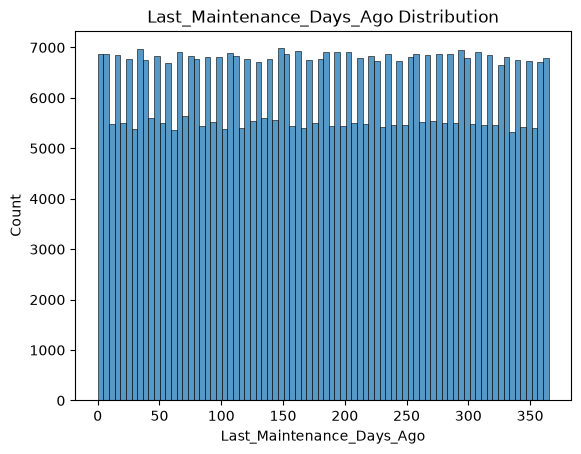

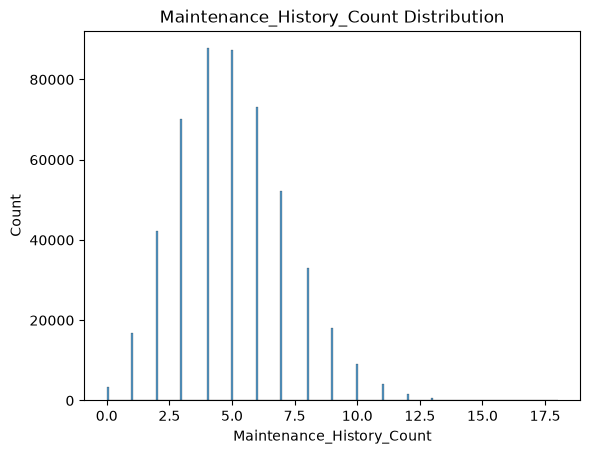

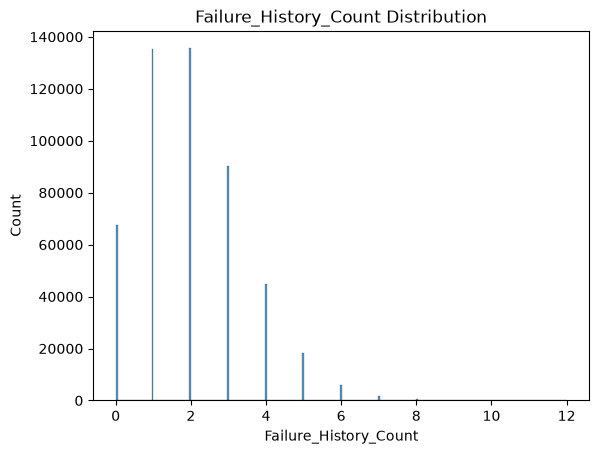

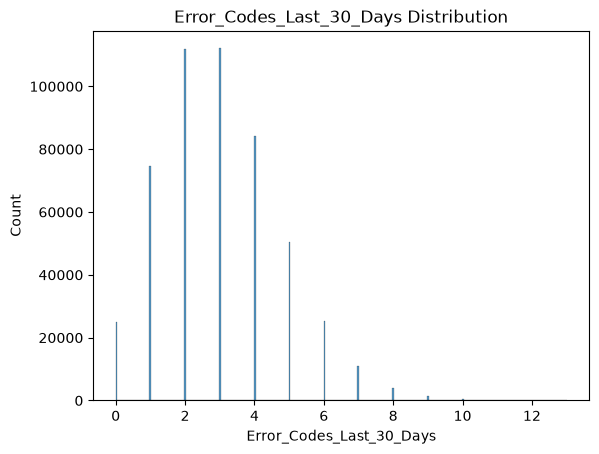

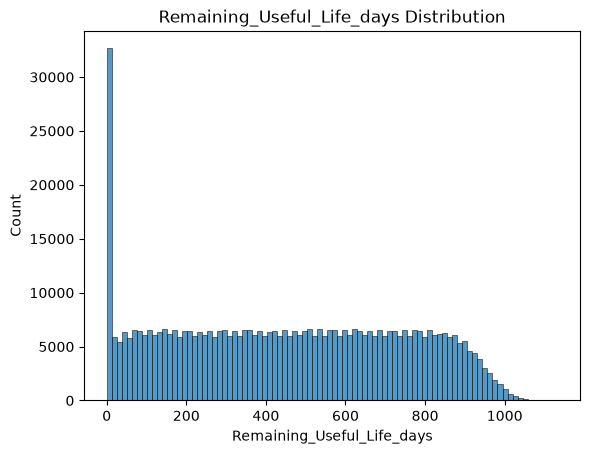

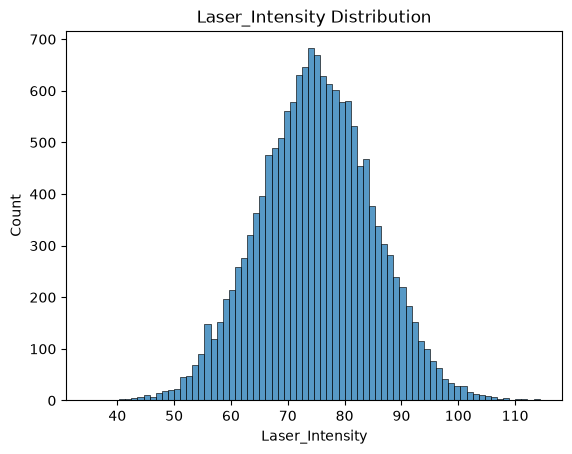

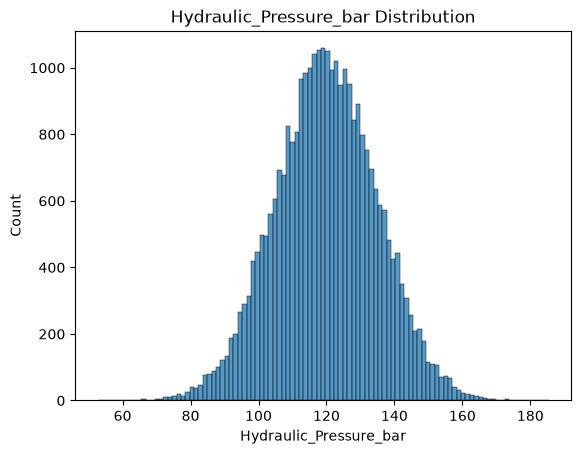

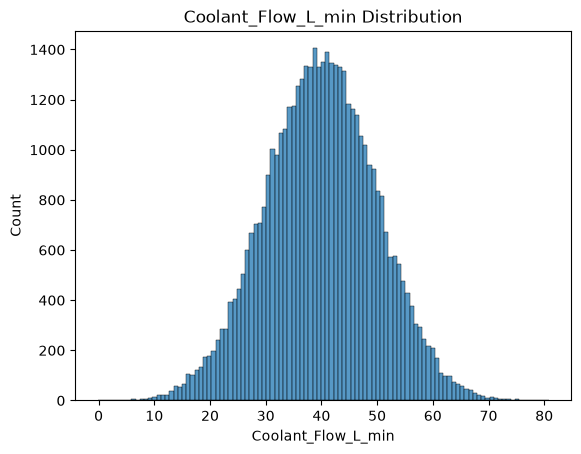

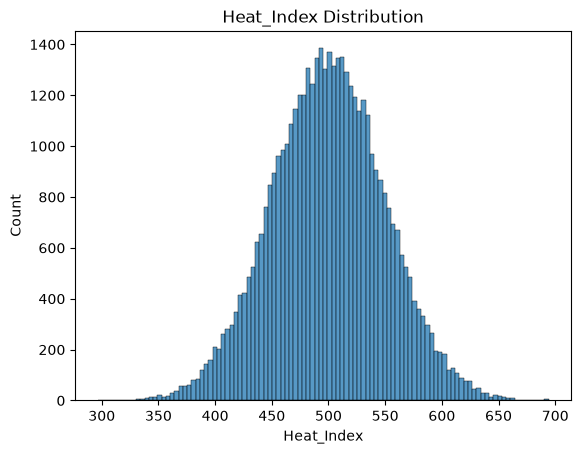

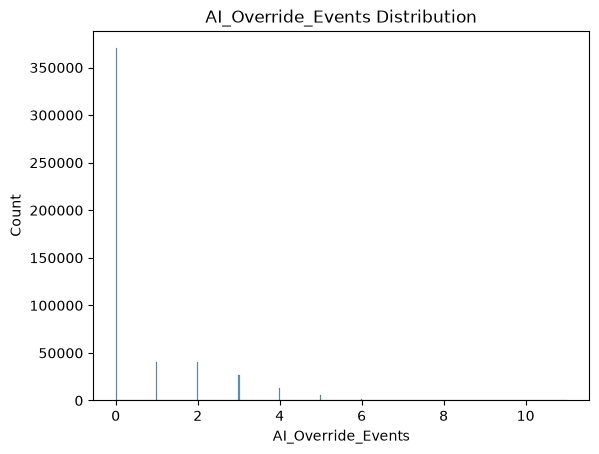

In [51]:
for col in df.select_dtypes(include=[np.number]):
    sns.histplot(df[col].dropna())
    plt.title(col + " Distribution")
    plt.show()
# Since the majority of the data has a normal distribution, no outliers are needed to be handled.

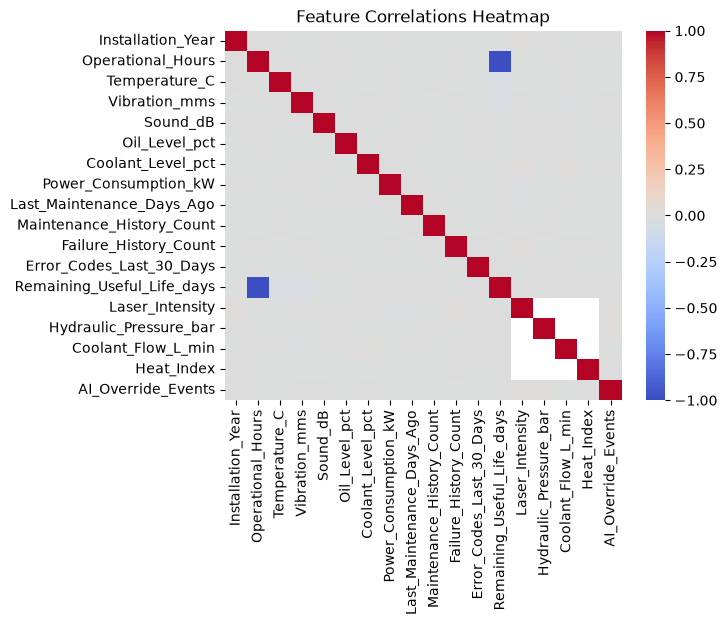

In [52]:
corr_map = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_map, cmap='coolwarm', vmin=-1, center=0, vmax=1)
plt.title("Feature Correlations Heatmap")
plt.show()

# 2) Data Cleaning
---
#### Handeling:
- Duplicates
- Nulls
- Dropping Unnecessary Columns

#### 1) Duplicate rows

A) Checking for duplicate rows

In [53]:
df.drop('Machine_ID', axis=1).duplicated().sum()

np.int64(0)

#### 2) Null Values

A) Checking for Nulls

In [54]:
df.isna().sum()

Machine_ID                         0
Machine_Type                       0
Installation_Year                  0
Operational_Hours                  0
Temperature_C                      0
Vibration_mms                      0
Sound_dB                           0
Oil_Level_pct                      0
Coolant_Level_pct                  0
Power_Consumption_kW               0
Last_Maintenance_Days_Ago          0
Maintenance_History_Count          0
Failure_History_Count              0
AI_Supervision                     0
Error_Codes_Last_30_Days           0
Remaining_Useful_Life_days         0
Failure_Within_7_Days              0
Laser_Intensity               484844
Hydraulic_Pressure_bar        469660
Coolant_Flow_L_min            454376
Heat_Index                    454786
AI_Override_Events                 0
dtype: int64

B) Checking normal distribution for columns with Nulls

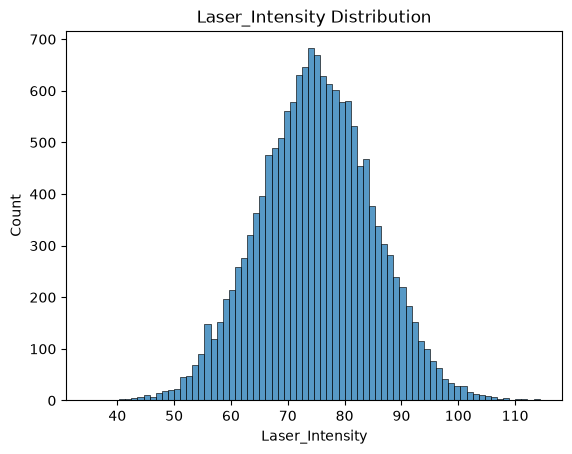

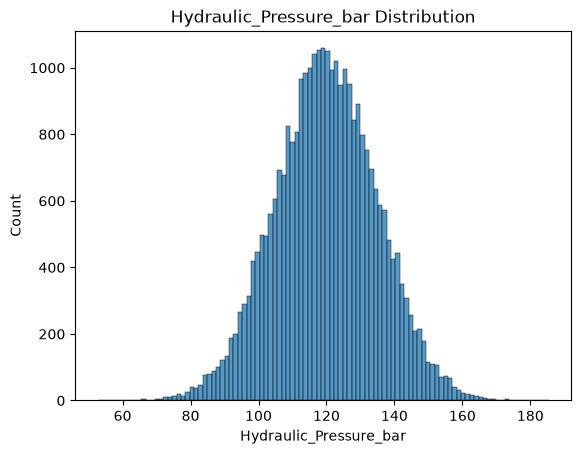

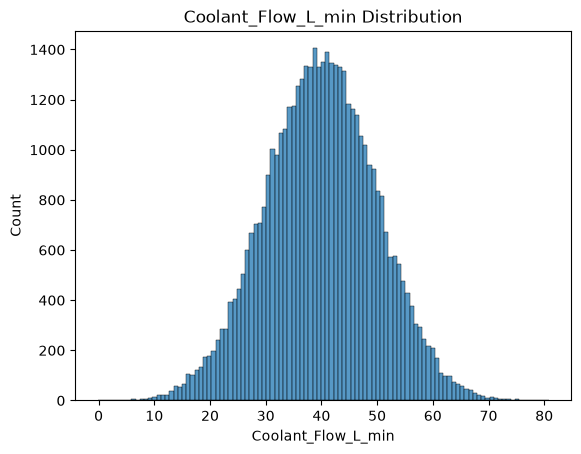

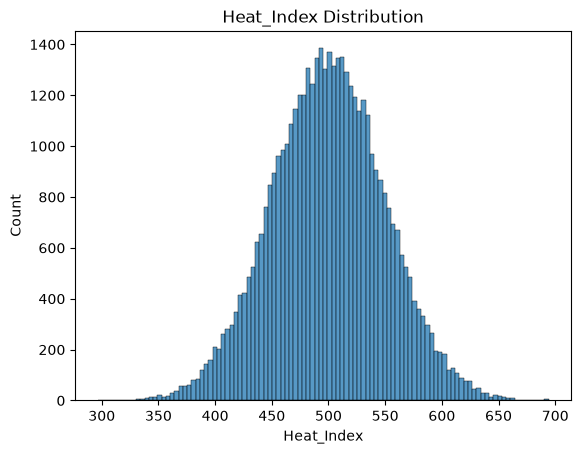

In [55]:
for col in ['Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index']:
    sns.histplot(df[col].dropna())
    plt.title(col + " Distribution")
    plt.show()
# Normal distribution for all columns.

C) Handeling Nulls

In [56]:
for col in ['Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index']:
    print(col, "has", (df[col] == 0).sum(), "rows with value 0")

Laser_Intensity has 0 rows with value 0
Hydraulic_Pressure_bar has 0 rows with value 0
Coolant_Flow_L_min has 0 rows with value 0
Heat_Index has 0 rows with value 0


In [57]:
for col in ['Laser_Intensity', 'Hydraulic_Pressure_bar', 'Coolant_Flow_L_min', 'Heat_Index']:
    df.fillna(0, inplace=True)

D) Assuring Null imputations done successfully

In [58]:
df.isna().sum()

Machine_ID                    0
Machine_Type                  0
Installation_Year             0
Operational_Hours             0
Temperature_C                 0
Vibration_mms                 0
Sound_dB                      0
Oil_Level_pct                 0
Coolant_Level_pct             0
Power_Consumption_kW          0
Last_Maintenance_Days_Ago     0
Maintenance_History_Count     0
Failure_History_Count         0
AI_Supervision                0
Error_Codes_Last_30_Days      0
Remaining_Useful_Life_days    0
Failure_Within_7_Days         0
Laser_Intensity               0
Hydraulic_Pressure_bar        0
Coolant_Flow_L_min            0
Heat_Index                    0
AI_Override_Events            0
dtype: int64

#### 3) Dropping unnecessary columns

In [59]:
df.drop(columns=['AI_Supervision', 'AI_Override_Events', ], inplace=True)

# 3) Feature Engineering
---

A) Flags

In [60]:
df['Flag_Critical_Fluid'] = np.where((df['Oil_Level_pct'] < df['Oil_Level_pct'].quantile(0.25)) | (df['Coolant_Level_pct'] < df['Coolant_Level_pct'].quantile(0.25)), 1, 0)
df['Flag_High_Stress'] = np.where((df['Temperature_C'] > df['Temperature_C'].quantile(0.75)) | (df['Vibration_mms'] > df['Vibration_mms'].quantile(0.75)), 1, 0)
df['Flag_Overdue_Maintenance'] = np.where(df['Last_Maintenance_Days_Ago'] > df['Last_Maintenance_Days_Ago'].quantile(0.75), 1, 0)

B) Years Segmentation

In [61]:
def assign_cohort(year):
    if year < 2000:
        return 'Legacy_Pre2000'
    elif 2000 <= year <= 2022:
        return 'Modern_Standard'
    else:
        return 'NextGen_FutureTech'

df['Machine_Tech_Cohort'] = df['Installation_Year'].apply(assign_cohort)

C) Errors

In [62]:
df['Maintenance_Decay_Factor'] = 1 - np.exp(-df['Last_Maintenance_Days_Ago'] / 90.0)
df['MTBF_Proxy'] = df['Operational_Hours'] / (df['Failure_History_Count'] + 1)
df['Maintenance_Inefficiency_Index'] = (df['Failure_History_Count'] + 1) / (df['Maintenance_History_Count'] + 1)

D) Efficiency Degradiations

In [63]:
eps = 1e-5
df['Specific_Vibration_Energy'] = (df['Vibration_mms']**2) / (np.log(df['Power_Consumption_kW'] + 1) + eps)
df['Cumulative_Mechanical_Stress'] = df['Operational_Hours'] * np.sqrt(df['Power_Consumption_kW'] * df['Temperature_C'])
type_temp_mean = df.groupby('Machine_Type')['Temperature_C'].transform('mean')
df['Thermal_Degradation_Index'] = np.exp(df['Temperature_C'] / (type_temp_mean + eps))

c:\Users\Mohamed Galal\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Mohamed Galal\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Mohamed Galal\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


E) Multivariate Anomalies z-scores

In [64]:
sensor_cols = ['Temperature_C', 'Vibration_mms', 'Sound_dB', 'Power_Consumption_kW']

for col in sensor_cols:
    mean = df.groupby('Machine_Type')[col].transform('mean')
    std = df.groupby('Machine_Type')[col].transform('std') + eps
    df[f'{col}_Z'] = (df[col] - mean) / std

df['Multivariate_Anomaly_Score'] = np.sqrt(
    df['Temperature_C_Z']**2 +
    df['Vibration_mms_Z']**2 +
    df['Sound_dB_Z']**2 +
    df['Power_Consumption_kW_Z']**2
)

df.drop(columns=[f'{col}_Z' for col in sensor_cols], inplace=True)

Reviewing dataset after changes

In [65]:
df

,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Flag_High_Stress,Flag_Overdue_Maintenance,Machine_Tech_Cohort,Maintenance_Decay_Factor,MTBF_Proxy,Maintenance_Inefficiency_Index,Specific_Vibration_Energy,Cumulative_Mechanical_Stress,Thermal_Degradation_Index,Multivariate_Anomaly_Score
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,1,0,NextGen_FutureTech,0.817316,13628.166667,1.200,36.671896,6.458135e+06,3.406865,1.587201
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,1,0,NextGen_FutureTech,0.779335,24988.666667,0.500,44.518317,7.118556e+06,2.648975,1.030154
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,0,Modern_Standard,0.943112,47003.000000,1.000,142.497354,4.771022e+06,2.289355,3.137390
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,...,0,0,Modern_Standard,0.379840,38318.500000,0.400,35.324653,5.319858e+06,2.883220,1.493150
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,...,0,1,Modern_Standard,0.978602,6956.666667,0.600,3.604345,2.046990e+06,2.040890,2.862918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,MC_499995,Vacuum_Packer,2011,14425,65.42,16.50,81.95,59.21,73.67,255.87,...,1,1,Modern_Standard,0.956428,3606.250000,0.800,49.066607,1.866297e+06,2.976636,2.014763
499996,MC_499996,Conveyor_Belt,2003,75501,44.83,12.88,64.94,73.69,29.25,198.37,...,0,0,Modern_Standard,0.900849,37750.500000,0.400,31.329367,7.119919e+06,2.110125,1.653235
499997,MC_499997,CMM,2039,19855,37.26,11.46,70.70,70.70,49.04,156.59,...,0,0,NextGen_FutureTech,0.871978,6618.333333,0.375,25.954827,1.516608e+06,1.860585,1.627517
499998,MC_499998,Dryer,2035,86823,67.72,16.76,77.45,97.00,15.40,132.33,...,1,0,NextGen_FutureTech,0.952377,28941.000000,0.750,57.409962,8.219065e+06,3.079175,1.486926


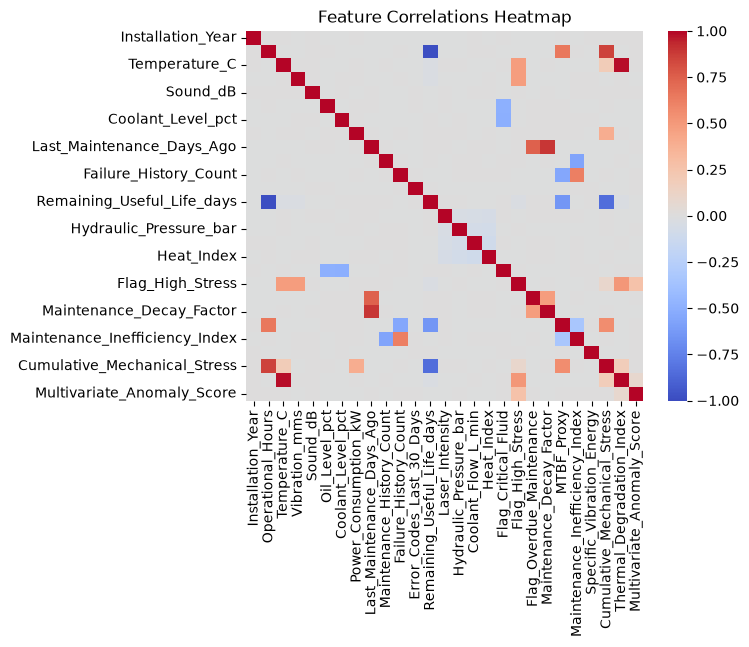

In [69]:
corr_map = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_map, cmap='coolwarm', vmin=-1, center=0, vmax=1)
plt.title("Feature Correlations Heatmap")
plt.show()

# 4) Data Analysis
---

### Machine types with has the highest average operational hours

In [66]:
df.groupby('Machine_Type')['Operational_Hours'].mean().sort_values(ascending=False).to_frame()
# Palletizer has the highest average operational hours.

,Operational_Hours
Machine_Type,
Palletizer,50337.610931
Crane,50331.072582
Grinder,50326.816601
Pump,50323.834121
Furnace,50261.320689
CNC_Mill,50244.288303
CNC_Lathe,50214.587247
Valve_Controller,50189.671800
Pick_and_Place,50168.053450


### Modern VS old machinery power consumptions

In [70]:
df.groupby('Machine_Tech_Cohort')['Power_Consumption_kW'].sum().to_frame()

,Power_Consumption_kW
Machine_Tech_Cohort,
Modern_Standard,42177600.32
NextGen_FutureTech,32783480.02


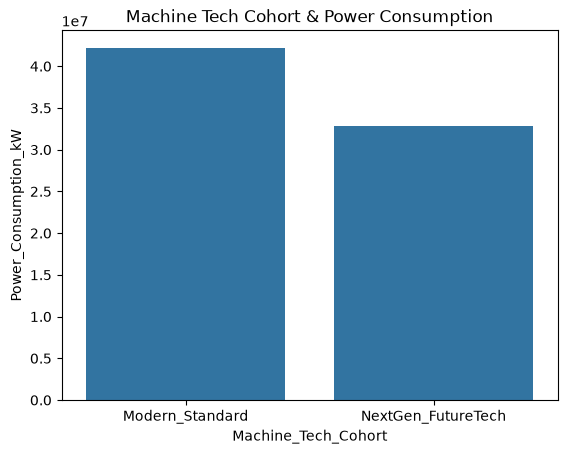

In [77]:
sns.barplot(df.groupby('Machine_Tech_Cohort')['Power_Consumption_kW'].sum())
plt.title("Machine Tech Cohort & Power Consumption")
plt.show()

### Critical fluids percentage

In [100]:
critical_fluids = df['Flag_Critical_Fluid'].value_counts().to_frame()
critical_fluids['Percentage'] = (critical_fluids['count'] / critical_fluids['count'].sum())*100
critical_fluids

,count,Percentage
Flag_Critical_Fluid,,
0,281388,56.2776
1,218612,43.7224
